# Notebook 03 – Supervised Classification: High-Value-Customer erkennen

Dieses Notebook baut auf dem bereinigten Datensatz aus Notebook 01 auf.
Ziel ist es, mithilfe von Supervised Learning vorherzusagen, ob ein Kunde
zu den umsatzstärksten 25 % gehört (**High-Value-Customer**).

Da der Datensatz keine vorgefertigte Zielvariable enthält, wird diese
aus dem Gesamtumsatz abgeleitet.

**Ablauf:**
1. Bereinigten Datensatz laden
2. Kundendaten aggregieren
3. Zielvariable `HighValueCustomer` erstellen
4. Features und Zielvariable definieren
5. Train-Test-Split und Skalierung
6. Drei Modelle trainieren und vergleichen
7. Bestes Modell detailliert auswerten

## 1. Bibliotheken importieren

In [32]:
# Datenverarbeitung
import pandas as pd
import numpy as np

# Visualisierung
import matplotlib.pyplot as plt

# Machine Learning: Modelle und Evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Bereinigten Datensatz laden

Der Datensatz wurde in Notebook 01 bereinigt (Stornierungen und ungültige
Einträge wurden entfernt). Er wird hier direkt eingelesen.

In [33]:
df = pd.read_csv(
    "../data/online_retail_data_cleaned.csv",
    parse_dates=["InvoiceDate"]
)

df.head()

/tmp/ipykernel_3655/311456575.py:1: DtypeWarning: Columns (0: InvoiceNo) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceMonth,IsCancellation
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01,False
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,False


## 3. Kundendaten aggregieren

Der Datensatz enthält einzelne Rechnungspositionen. Für die Klassifikation
wird eine Kundensicht benötigt: eine Zeile pro Kunde mit zusammengefassten Merkmalen.

Berechnete Merkmale:
- `total_revenue`: Gesamtumsatz
- `number_of_orders`: Anzahl eindeutiger Rechnungen
- `total_quantity`: Gesamtmenge aller Artikel
- `unique_products`: Anzahl unterschiedlicher Produkte
- `avg_order_value`: Durchschnittlicher Bestellwert

In [34]:
customer_data = df.groupby("CustomerID").agg({
    "TotalPrice": "sum",
    "InvoiceNo": "nunique",
    "Quantity": "sum",
    "StockCode": "nunique"
}).reset_index()

customer_data.columns = [
    "CustomerID",
    "total_revenue",
    "number_of_orders",
    "total_quantity",
    "unique_products"
]

# Durchschnittlicher Bestellwert als abgeleitetes Merkmal
customer_data["avg_order_value"] = (
    customer_data["total_revenue"] / customer_data["number_of_orders"]
)

customer_data.head()

,CustomerID,total_revenue,number_of_orders,total_quantity,unique_products,avg_order_value
0,12346.0,77183.60,1,74215.0,1,77183.600000
1,12347.0,4310.00,7,2458.0,103,615.714286
2,12348.0,1797.24,4,2341.0,22,449.310000
3,12349.0,1757.55,1,631.0,73,1757.550000
4,12350.0,334.40,1,197.0,17,334.400000


## 4. Zielvariable erstellen: HighValueCustomer

Da der Datensatz keine fertige Zielvariable enthält, wird eine eigene erstellt.
Ein Kunde gilt als **High-Value-Customer**, wenn sein Gesamtumsatz zu den
oberen 25 % aller Kunden gehört (75. Perzentil).

- `1` = High-Value-Customer (Top 25 %)
- `0` = Normaler Kunde

In [35]:
# Schwellenwert: 75. Perzentil des Gesamtumsatzes
threshold = customer_data["total_revenue"].quantile(0.75)
print(f"Schwellenwert (75. Perzentil): {threshold:,.2f} €")

# Zielvariable erstellen
customer_data["HighValueCustomer"] = (
    customer_data["total_revenue"] >= threshold
).astype(int)

# Klassenverteilung prüfen
print("\nKlassenverteilung:")
print(customer_data["HighValueCustomer"].value_counts())

Schwellenwert (75. Perzentil): 1,661.74 €

Klassenverteilung:
HighValueCustomer
0    3253
1    1085
Name: count, dtype: int64


## 5. Features und Zielvariable definieren

Als Features werden nur Merkmale verwendet, die **nicht** direkt die Zielvariable
erzeugen. `total_revenue` wird deshalb bewusst ausgeschlossen: Würde man es als
Feature verwenden, hätte das Modell die Lösung direkt im Input – das nennt man
**Data Leakage** und würde zu unrealistisch guten Ergebnissen führen.

In [36]:
# Features ohne total_revenue (Data Leakage vermeiden)
features = [
    "number_of_orders",
    "total_quantity",
    "unique_products",
    "avg_order_value"
]

X = customer_data[features]
y = customer_data["HighValueCustomer"]

X.head()

,number_of_orders,total_quantity,unique_products,avg_order_value
0,1,74215.0,1,77183.600000
1,7,2458.0,103,615.714286
2,4,2341.0,22,449.310000
3,1,631.0,73,1757.550000
4,1,197.0,17,334.400000


## 6. Train-Test-Split

Die Daten werden 80/20 in Trainings- und Testdaten aufgeteilt.
`stratify=y` stellt sicher, dass das Klassenverhältnis in beiden Teilen
annähernd gleich bleibt.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Trainingsdaten: {X_train.shape}")
print(f"Testdaten:      {X_test.shape}")

Trainingsdaten: (3470, 4)
Testdaten:      (868, 4)


## 7. Skalierung der Features

Für KNN ist Skalierung zwingend erforderlich, da das Modell auf Basis von Distanzen
arbeitet – unterschiedliche Größenordnungen der Features würden das Ergebnis stark
verzerren. Damit alle drei Modelle auf denselben Daten vergleichbar sind, werden
die skalierten Daten für alle Modelle verwendet.

Wichtig: Der Scaler wird **nur auf den Trainingsdaten** trainiert (`fit_transform`)
und dann auf die Testdaten angewendet (`transform`).
Ein `fit_transform` auf den Testdaten würde Informationen aus dem Test-Set
in die Vorverarbeitung einbeziehen (Data Leakage).

In [38]:
scaler = StandardScaler()

# fit_transform nur auf Trainingsdaten
X_train_scaled = scaler.fit_transform(X_train)

# transform (kein fit!) auf Testdaten
X_test_scaled = scaler.transform(X_test)

## 8. Modelle trainieren

Drei Klassifikationsmodelle werden trainiert und verglichen:

1. **Decision Tree**: regelbasiert, gut interpretierbar
2. **K-Nearest Neighbors (KNN)**: instanzbasiert, arbeitet mit Distanzen
3. **Naive Bayes**: probabilistisch, schnell und einfach

In [39]:
# Decision Tree (max_depth=5 verhindert Overfitting)
decision_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
decision_tree.fit(X_train_scaled, y_train)

# K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Naive Bayes
naive_bayes = GaussianNB()
naive_bayes.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## 9. Modelle vergleichen

Die Modelle werden zunächst anhand der Accuracy verglichen.
Accuracy gibt an, wie viele Vorhersagen insgesamt korrekt waren.

In [40]:
models = {
    "Decision Tree": decision_tree,
    "KNN": knn,
    "Naive Bayes": naive_bayes
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name}: Accuracy = {accuracy:.4f}")

Decision Tree: Accuracy = 0.9654
KNN: Accuracy = 0.9654
Naive Bayes: Accuracy = 0.9055


## 10. Classification Report – Decision Tree

Der Decision Tree wird genauer ausgewertet, da er das am besten interpretierbare
Modell ist. Der Classification Report zeigt:

- **Precision**: Wie viele der als High-Value-Customer vorhergesagten Kunden sind es wirklich?
- **Recall**: Wie viele der echten High-Value-Customer wurden erkannt?
- **F1-Score**: Harmonisches Mittel aus Precision und Recall

In [41]:
best_model = decision_tree
y_pred = best_model.predict(X_test_scaled)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal Customer", "High-Value Customer"]
))

                     precision    recall  f1-score   support

    Normal Customer       0.97      0.99      0.98       651
High-Value Customer       0.96      0.90      0.93       217

           accuracy                           0.97       868
          macro avg       0.96      0.94      0.95       868
       weighted avg       0.97      0.97      0.97       868



## 11. Confusion Matrix

Die Confusion Matrix zeigt, wie viele Kunden richtig und wie viele falsch
klassifiziert wurden (True/False Positives und Negatives).

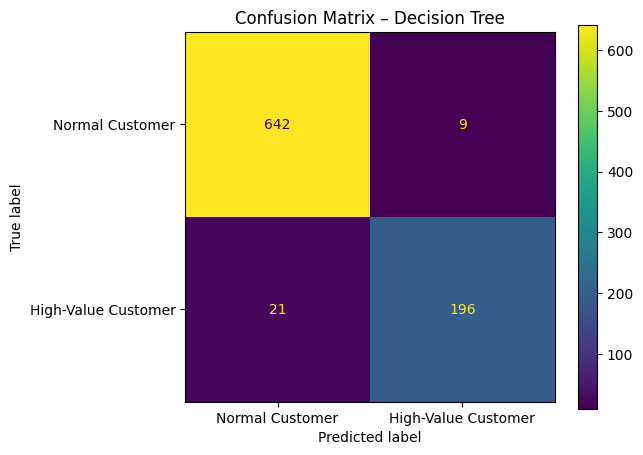

In [42]:
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal Customer", "High-Value Customer"]
)

display.plot()
plt.title("Confusion Matrix – Decision Tree")
plt.tight_layout()
plt.savefig("../output/03_confusion_matrix_decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Decision Tree visualisieren

Ein wesentlicher Vorteil des Decision Trees ist die grafische Darstellbarkeit.
So lässt sich nachvollziehen, nach welchen Regeln das Modell Entscheidungen trifft.

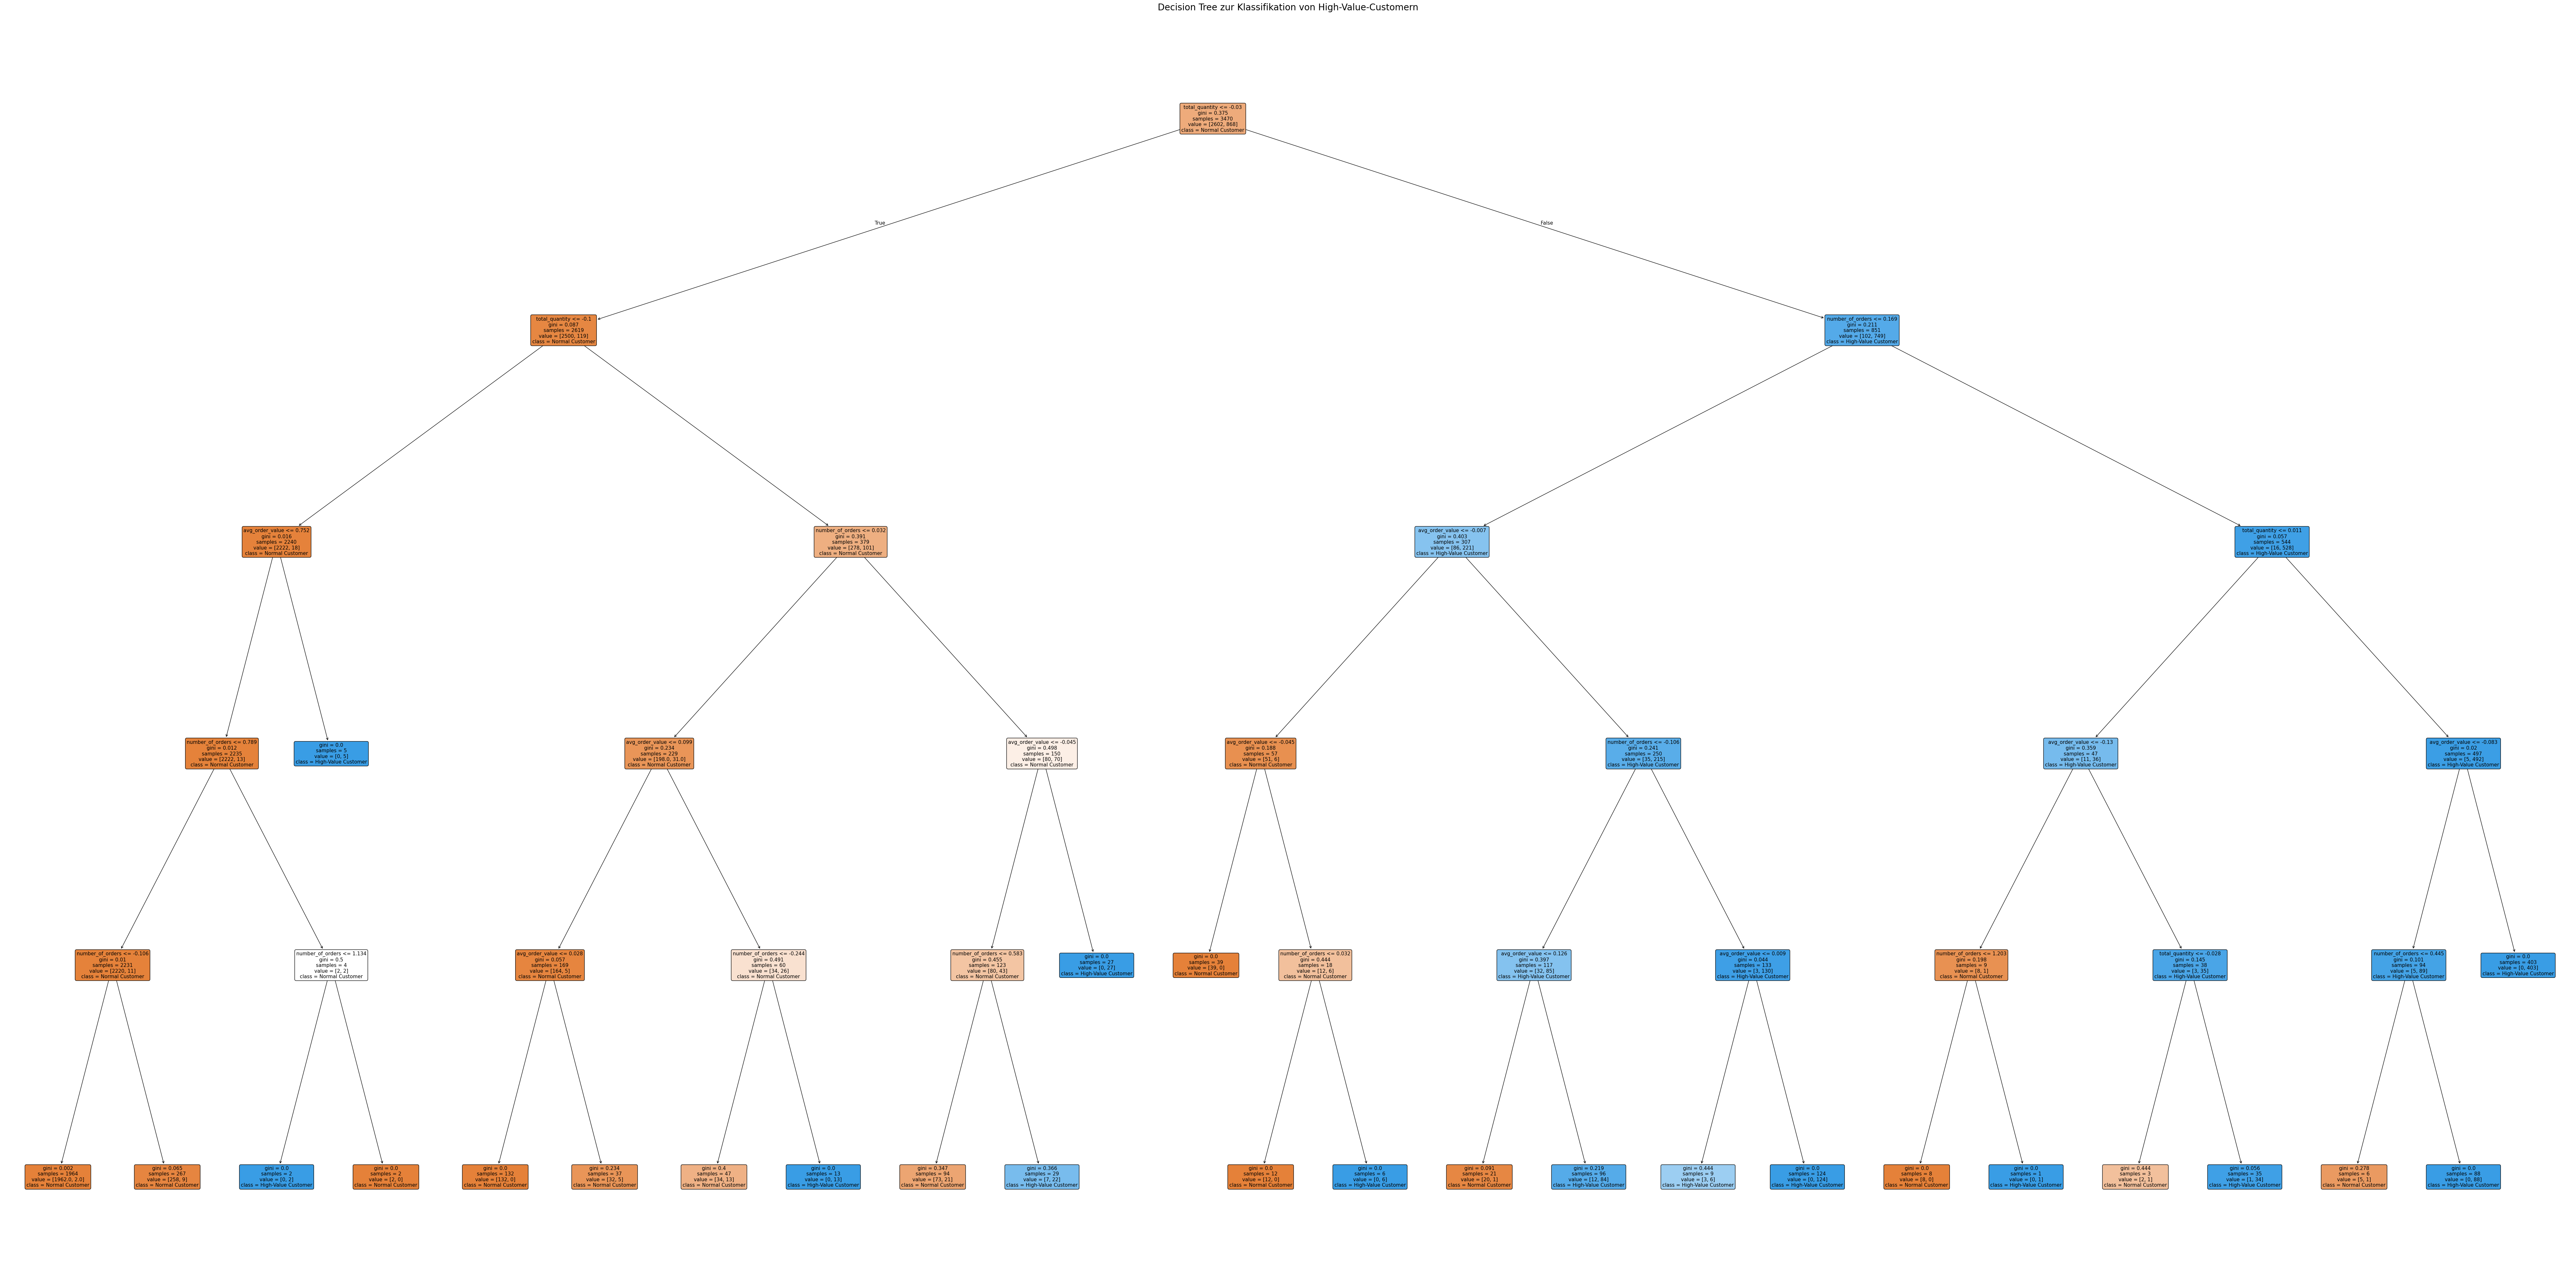

In [43]:
plt.figure(figsize=(80, 40))

plot_tree(
    decision_tree,
    feature_names=features,
    class_names=["Normal Customer", "High-Value Customer"],
    filled=True,
    rounded=True,
    fontsize=11
)

plt.title("Decision Tree zur Klassifikation von High-Value-Customern", fontsize=20)
plt.tight_layout()
plt.savefig("../output/03_decision_tree_visualisierung.png", dpi=80, bbox_inches="tight")
plt.show()

Da der vollständige Baum (Tiefe 5) sehr komplex und schwer lesbar ist,
zeigen wir hier zusätzlich eine vereinfachte Darstellung mit nur 2 Ebenen.
Diese zeigt die wichtigsten Entscheidungsregeln auf einen Blick.

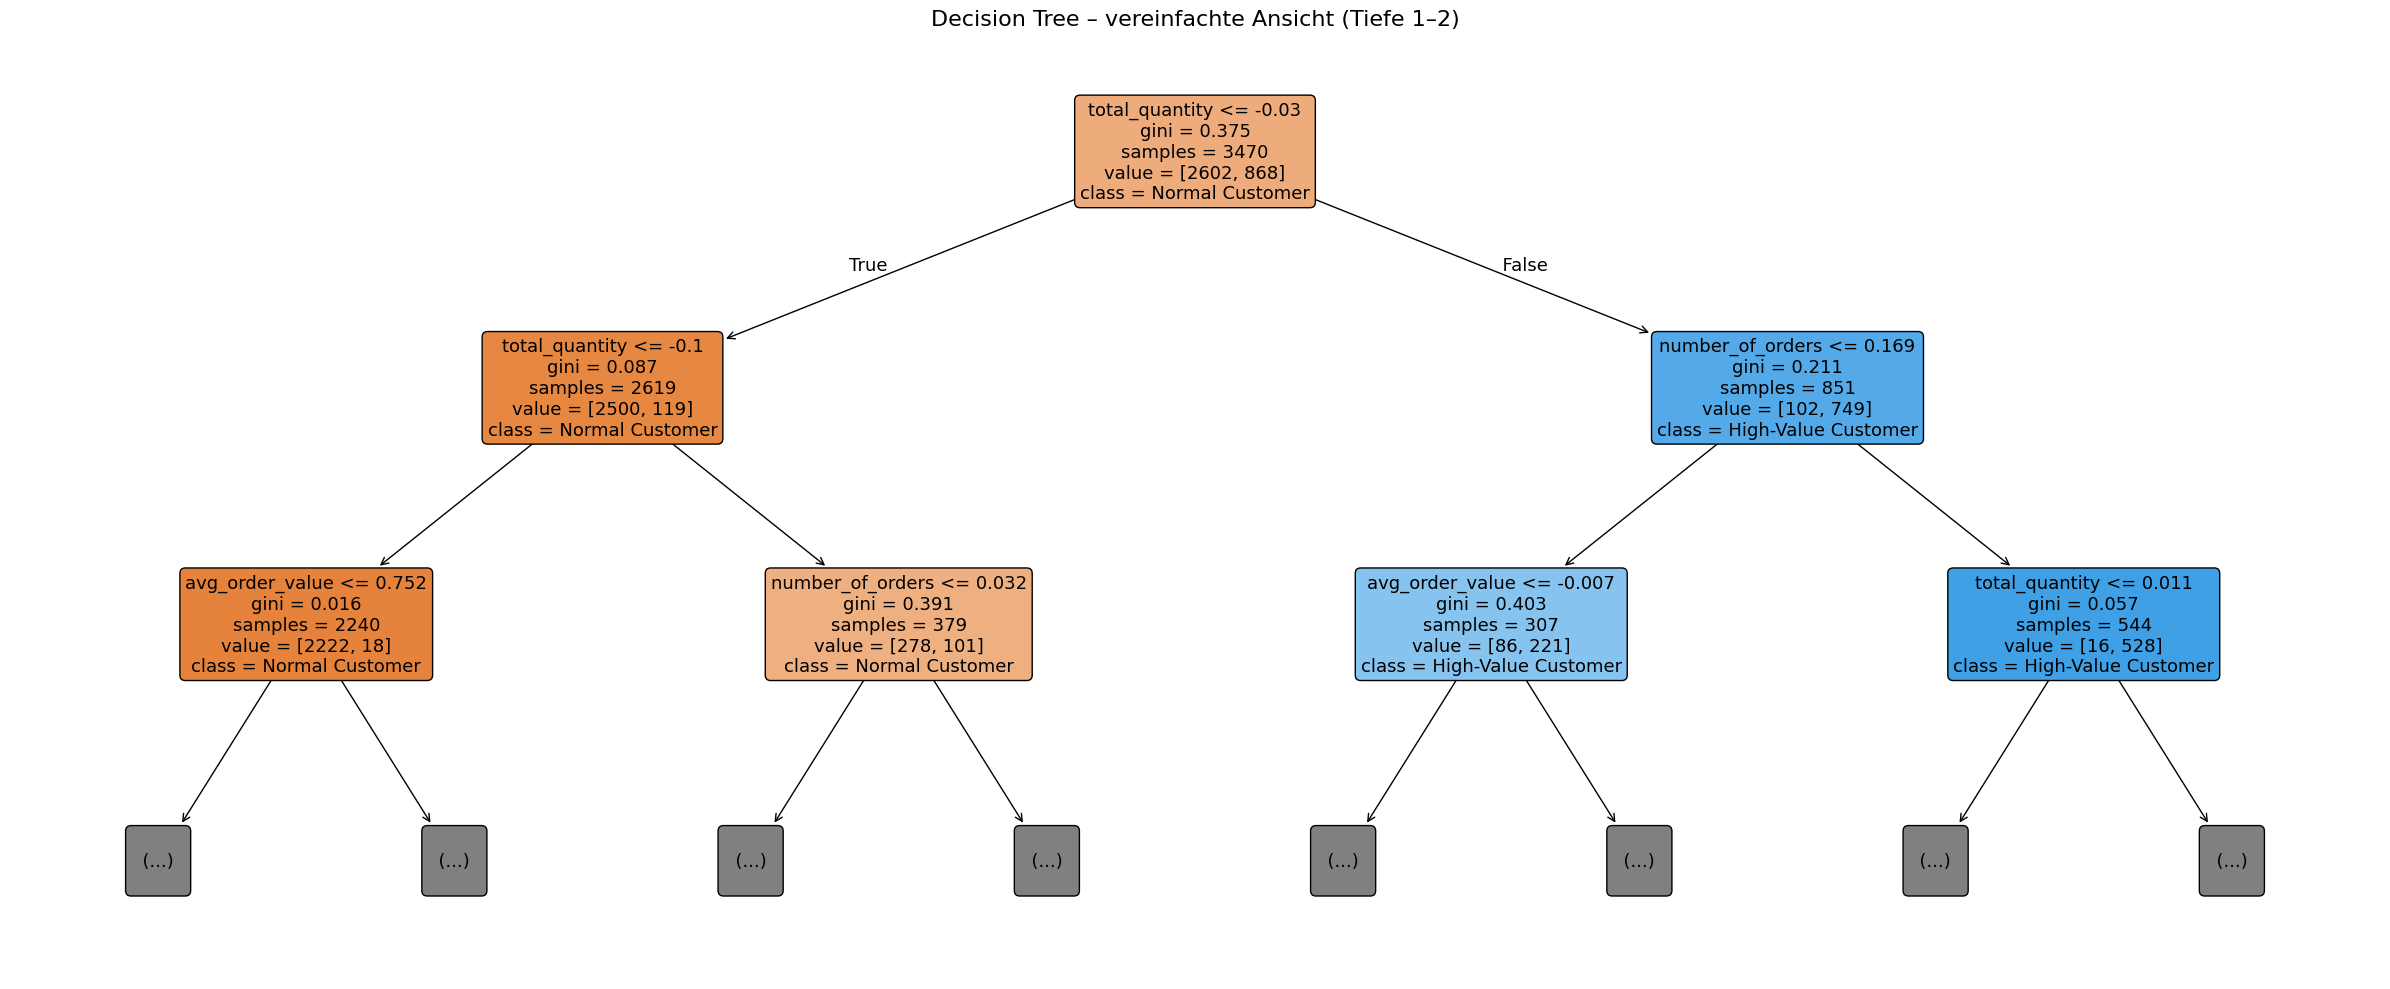

In [44]:
plt.figure(figsize=(24, 10))

plot_tree(
    decision_tree,
    feature_names=features,
    class_names=["Normal Customer", "High-Value Customer"],
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=13
)

plt.title("Decision Tree – vereinfachte Ansicht (Tiefe 1–2)", fontsize=16)
plt.tight_layout()
plt.savefig("../output/03_decision_tree_visualisierung_vereinfacht.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Feature Importance

Die Feature Importance zeigt, welche Merkmale für die Entscheidungen
des Decision Trees am stärksten ausschlaggebend waren.

         Feature  Importance
  total_quantity    0.802229
 avg_order_value    0.114735
number_of_orders    0.083036
 unique_products    0.000000


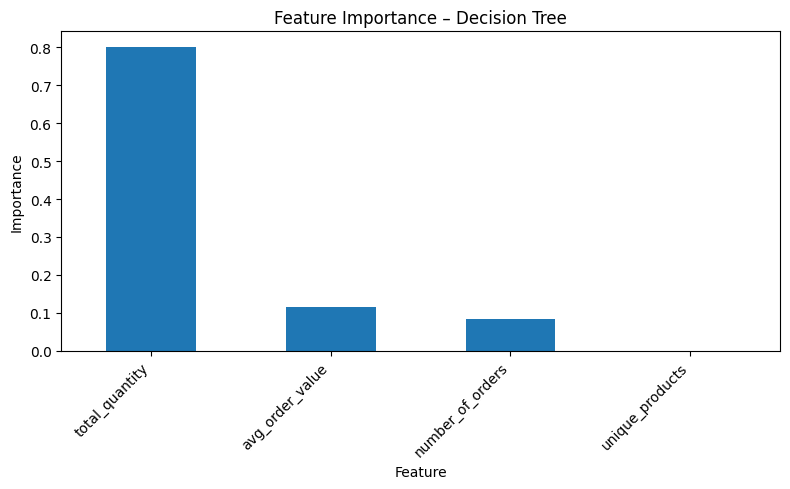

In [45]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": decision_tree.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.to_string(index=False))

feature_importance.plot(
    kind="bar",
    x="Feature",
    y="Importance",
    legend=False,
    figsize=(8, 5)
)
plt.title("Feature Importance – Decision Tree")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../output/03_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Fazit

In diesem Notebook wurde ein Supervised-Classification-Modell erstellt,
das Kunden als *normaler Kunde* oder *High-Value-Customer* klassifiziert.

Wichtigste Ergebnisse:
- Decision Tree und KNN erreichen eine Accuracy von ca. 96–97 %
- Data Leakage wurde durch den Ausschluss von `total_revenue` aus den Features vermieden
- Die Feature Importance zeigt, welche Kundenmerkmale am stärksten zur
  Vorhersage beitragen

Im nächsten Notebook (04) wird nicht mehr klassifiziert, sondern der
genaue Kundenumsatz als kontinuierliche Zielgröße vorhergesagt (Regression).